In [71]:
import matplotlib.pyplot as plt 
import numpy as np
import IPython.display as ipd
from scipy.io import wavfile
import scipy as sp


In [36]:
#formula
sinusoid = lambda amplitude, frequency, phase, t: amplitude * np.sin(2*np.pi*(frequency*t - phase))

In [37]:
def generate_periodic_signal(duration, amplitude, frequency, phase, sampling_frequency_1, sinusoid):
     #measuring the signal at evenly spaced time points
     num_samples = int(sampling_frequency_1 * duration)
     t = np.arange(num_samples) / sampling_frequency_1
     x = sinusoid(amplitude, frequency, phase, t)
     return x, t


duration = 1
amplitude = 4
frequency = 4
phase  = 0
sampling_frequency_1 = 1000
sampling_frequency_2 = 100

x, t  = generate_periodic_signal(duration, amplitude, frequency, phase, sampling_frequency_1, sinusoid)
#print(x,t)

In [38]:
# add nyquist theorem validation
def sample_signal(t, x, duration, sampling_frequency_2, max_frequency):
     Nyquist_sampling_rate = 2*max_frequency
     if sampling_frequency_2 < Nyquist_sampling_rate:
         print(f"{RED}The sampling rate to successfully reconstruct this signal according to the Nyquist theorem is {Nyquist_sampling_rate}{RESET}")
     
     num_samples_2 = int(sampling_frequency_2 * duration)
     t_discrete = np.arange(num_samples_2) / sampling_frequency_2
     x_discrete = np.interp(t_discrete, t, x)
     return x_discrete, t_discrete

#max frequency is just 4 since it's a periodic sinusoid
x_discrete, t_discrete = sample_signal(t, x, duration, sampling_frequency_2, frequency)

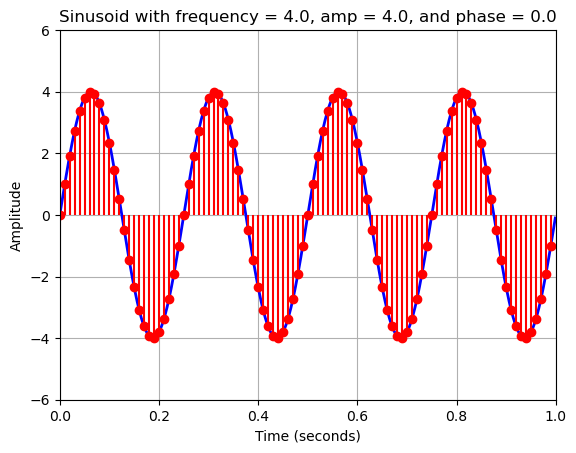

In [39]:

def display_graph(x, t, x2, t2, label, x_lim, a_lim):
     plt.plot(t, x, color='blue', linewidth=2.0, linestyle='-')
     plt.xlim(x_lim)
     plt.ylim(a_lim)
     plt.xlabel('Time (seconds)')
     plt.ylabel('Amplitude')
     plt.title(label)
     plt.stem(t2, x2, linefmt='r', markerfmt='ro', basefmt='None')
     plt.grid()
     plt.show()


label = 'Sinusoid with frequency = %.1f, amp = %.1f, and phase = %.1f' % (frequency, amplitude, phase)
display_graph(x, t, x_discrete, t_discrete, label, [0, duration], [-6, 6])


In [40]:
    
def hear_signal(x, sampling_frequency, rate_scale = 1):
      if sampling_frequency * rate_scale < 20:
        print("Playback rate too low for audible sound.")
        return
      x = x / np.max(np.abs(x))
    
      ipd.display(ipd.Audio(t, rate = sampling_frequency))

hear_signal(x, sampling_frequency_1)

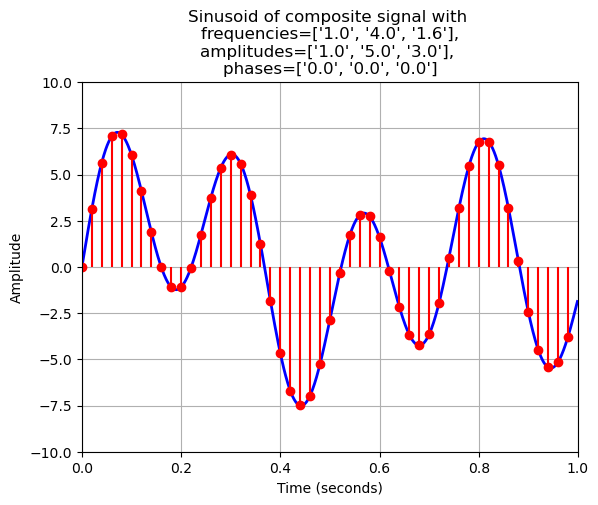

In [41]:
def generate_composite_periodic_signal(amplitudes, frequencies, phases, sinusoid, duration, sampling_frequency_1):
    signal_matrix = np.array([amplitudes, frequencies, phases]).T
    x_total = None
    t = None
    N = int(sampling_frequency_1 * duration)
    t = np.arange(N) / sampling_frequency_1
    for row in signal_matrix:
        amplitude, frequency, phase = row
        x  = sinusoid(amplitude, frequency, phase, t)
        if x_total is None:
                x_total = x
        else:
                x_total += x
    return x_total, t


amplitudes  = [1,5,3]
frequencies = [1,4,1.6]
phases      = [0, 0, 0]
sampling_frequency_composite = 1000
sampling_frequency_composite_2 = 50
duration = 1

max_frequency_composite = max(frequencies)
x_composite, t_composite = generate_composite_periodic_signal(amplitudes, frequencies, phases, sinusoid, duration, sampling_frequency_composite)
x_discrete_composite, t_discrete_composite = sample_signal(t_composite, x_composite, duration, sampling_frequency_composite_2,  max_frequency_composite)
label = (
    "Sinusoid of composite signal with "
    f"\nfrequencies={[f'{f:.1f}' for f in frequencies]},"
    f"\namplitudes={[f'{a:.1f}' for a in amplitudes]}, "
    f"\nphases={[f'{p:.1f}' for p in phases]}"
    )
display_graph(x_composite, t_composite, x_discrete_composite, t_discrete_composite, label, [0, 1], [-10,10] )


In [42]:
#cd audio is 16 bits so it is acceptable
def quantize_signal(x_discrete, bits = 16):
    levels = 2**bits
    x_min = np.min(x_discrete)
    x_max = np.max(x_discrete)
    q = (x_max - x_min) / levels
    x_quantized = q * np.round(x_discrete / q)
    return x_quantized

In [43]:
#fix !!!! make that grid start from 0 and remove padding left and right
def show_quantized_signal(x_quantized, t_discrete, x, t, x_lim = None, a_lim = None):
    if x_lim is None:
        x_lim = [t[0], t[-1]]
    if a_lim is None:
        max_amp = max(abs(x).max(), abs(x_quantized).max())
        a_lim = [-1.2 * max_amp, 1.2 * max_amp]
    plt.xlim(x_lim)
    plt.ylim(a_lim)
    plt.plot(t, x, label="Analog signal")
    plt.step(t_discrete, x_quantized, where='mid', label="Digital signal")
    plt.legend()
    plt.grid()
    plt.show()


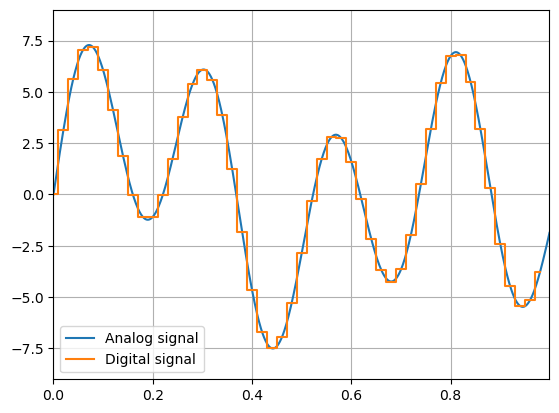

In [44]:
x_quantized_composite = quantize_signal(x_discrete_composite)
show_quantized_signal(x_quantized_composite, t_discrete_composite, x_composite, t_composite)

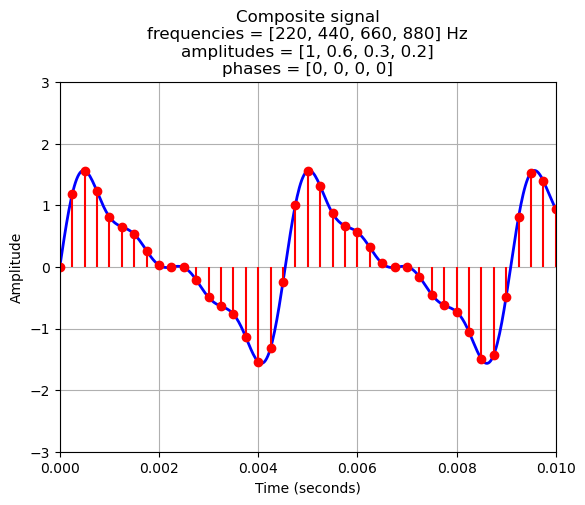

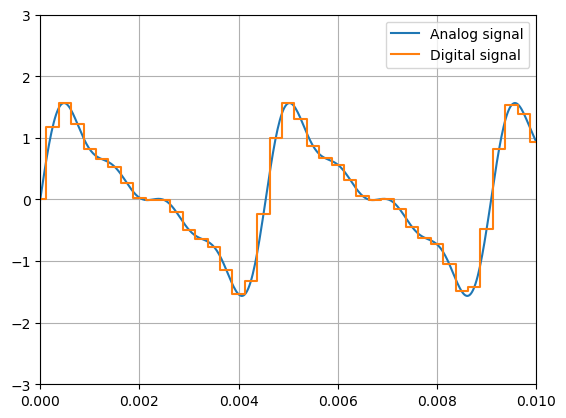

Signal before being ADC processed


Signal after being ADC processed


In [51]:
amplitudes_real  = [1, 0.6, 0.3, 0.2]
frequencies_real = [220, 440, 660, 880]
phases_real      = [0, 0, 0, 0]

sampling_frequency_composite_real = 44100
sampling_frequency_composite_2_real = 4000
duration_real = 1

max_frequency_real  = max(frequencies_real)

x_composite_real, t_composite_real = generate_composite_periodic_signal(
    amplitudes_real,
    frequencies_real,
    phases_real,
    sinusoid,
    duration_real,
    sampling_frequency_composite_real
)

x_discrete_composite_real, t_discrete_composite_real = sample_signal(
    t_composite_real,
    x_composite_real,
    duration_real,
    sampling_frequency_composite_2_real,
    max_frequency_real
)


label_real = (
    "Composite signal\n"
    f"frequencies = {[round(f,1) for f in frequencies_real]} Hz\n"
    f"amplitudes = {[round(a,2) for a in amplitudes_real]}\n"
    f"phases = {[round(p,1) for p in phases_real]}"
)


display_graph(
    x_composite_real,
    t_composite_real,
    x_discrete_composite_real,
    t_discrete_composite_real,
    label_real,
    [0, 0.01],
    [-3, 3]
)

x_quantized_composite_real = quantize_signal(x_discrete_composite_real)
show_quantized_signal(x_quantized_composite_real, t_discrete_composite_real, x_composite_real, t_composite_real, [0, 0.01], [-3, 3])
print("Signal before being ADC processed")
hear_signal(x, sampling_frequency_composite_real)
print("Signal after being ADC processed")



In [46]:
def compute_fft(x, sampling_frequency):
    N = len(x)
    X = np.fft.fft(x)
    frequencies = np.fft.fftfreq(N, d = 1/sampling_frequency)
    magnitudes = np.abs(X)
    frequencies = frequencies[:N//2]
    magnitudes = magnitudes[:N//2]
    return frequencies, magnitudes, N, X

In [47]:
fft_composite_real, magnitudes_real, N, X = compute_fft(x_quantized_composite_real, sampling_frequency_composite_2_real)


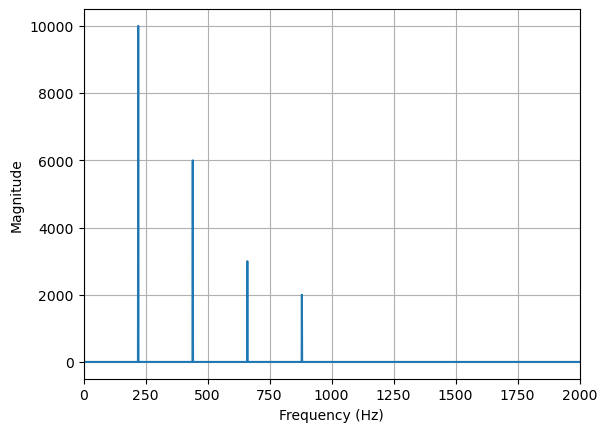

In [52]:
def show_spectrogram(frequencies, magnitudes, sampling_frequency, x_lim = None, y_lim = None):
    plt.plot(frequencies, magnitudes)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    if(x_lim == None):
        plt.xlim([0, 2000])
    else:
        plt.xlim(x_lim)

    if(y_lim != None):
        plt.ylim(y_lim)
    plt.grid()
    plt.show()

show_spectrogram(fft_composite_real, magnitudes_real, sampling_frequency_composite_2_real)

44100


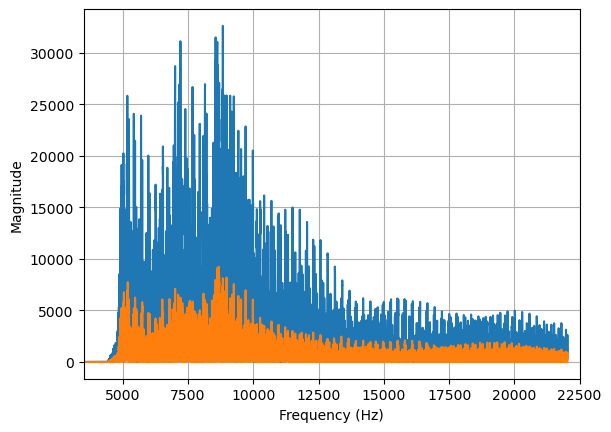

In [72]:
sampling_frequency_wav, signal = wavfile.read('lgs.wav');
wav_fft_frequencies, wav_magnitudes, N, X = compute_fft(signal, sampling_frequency_wav)
print(sampling_frequency_wav)
show_spectrogram(wav_fft_frequencies,  wav_magnitudes, sampling_frequency_wav, [3500, 22500] )

In [80]:
#finger printing is done using SFFT

def compute_sfft(x, sampling_frequency):
    ff, tt, Sxx = sp.signal.spectrogram(
        x,
        sampling_frequency,
        nperseg = 1024,
        noverlap = 768
    )
    Sxx_log = 10 * np.log10(Sxx + 1e-10)
    return ff, tt, Sxx, Sxx_log
    

In [81]:
def plot_sfft_spectrogram(ff, tt, Sxx):
    plt.figure(figsize=(10,6))
    plt.pcolormesh(tt, ff, Sxx)
    plt.xlabel("Time (seconds)")
    plt.ylabel("Frequency (Hz)")
    plt.title("Spectrogram")
    plt.colorbar(label="Intensity (dB)")

    plt.show()

In [84]:
if signal.ndim > 1:
    signal = signal.mean(axis=1)

ff, tt, Sxx, Sxx_log = compute_sfft(signal, sampling_frequency_wav)

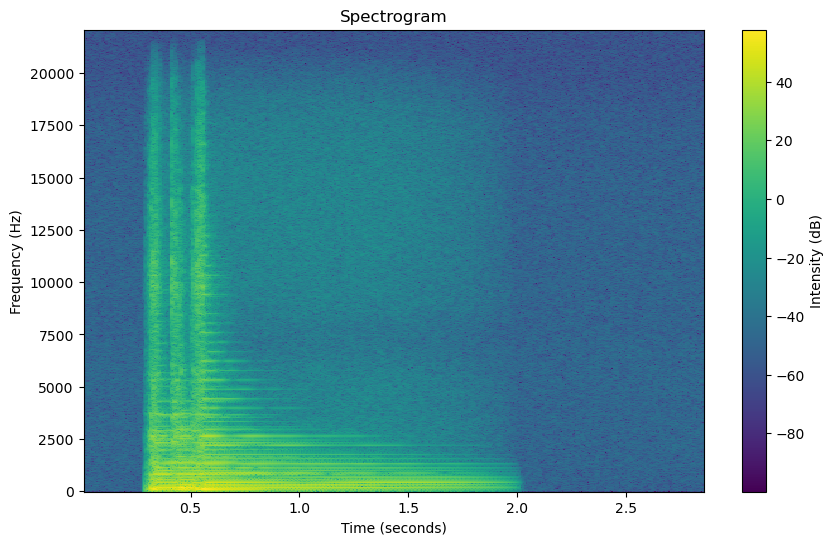

In [85]:
plot_sfft_spectrogram(ff, tt, Sxx_log)

In [94]:
def extract_peaks(Sxx_log, threshold=10):
    peaks = sp.ndimage.maximum_filter(Sxx_log, size=10) == Sxx_log
    rows, cols = np.where(peaks)
    peaks = [(col, row) for col, row in zip(cols, rows) if Sxx_log[row, col] > threshold]
    return peaks

In [99]:
def visualize_peaks(ff, tt, Sxx_log, peaks):
    plt.figure(figsize=(12,8))
    plt.pcolormesh(tt, ff, Sxx_log, shading='auto')
    plt.scatter( [tt[p[0]] for p in peaks], [ff[p[1]] for p in peaks], color='red', s=10, label="Peaks");
    plt.xlabel("Time (seconds)")
    plt.ylabel("Frequency (Hz)")
    plt.title("Spectrogram with Peaks")
    plt.colorbar(label="Intensity (dB)")
    plt.legend()
    plt.show()   

C:\Users\Mimi\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


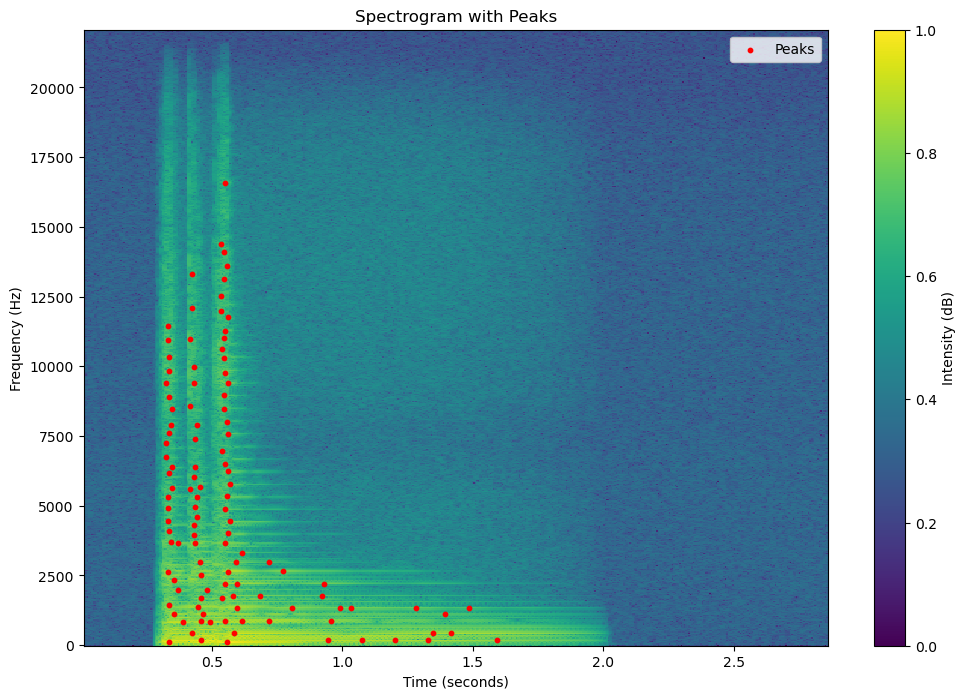

In [100]:
peaks =  extract_peaks(Sxx_log);
visualize_peaks(ff, tt, Sxx_log, peaks)

In [ ]:
def create_fingerprint():
    print('Find algorithm to create fingerprint')
    